# §4 Individual with ML#2 filter (v12 top-50 raw-Sharpe, V3 filter) — net of costs

Per-combo metrics and equity/drawdown curves after applying the
ML#2 booster + pooled-R:R isotonic calibrator filter.

**Cost model:** every trade is charged `contracts × $5.00` round-trip (≈ $3 retail commission + 2 ticks/side slippage on MNQ at $0.50/tick).

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd

REPO = Path.cwd().resolve()
while not (REPO / 'src').exists() and REPO.parent != REPO:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

from scripts.evaluation._top_perf_common import (
    STARTING_EQUITY, POLICIES,
    apply_sizing, metrics_from_pnl, monte_carlo,
    load_setup,
    plot_indiv_equity, plot_indiv_dd,
    plot_combined_equity, plot_combined_dd,
    plot_ml2_indiv_equity, plot_ml2_indiv_dd,
    plot_ml2_combined_equity, plot_ml2_combined_dd,
    plot_mc_sims, plot_mc_pnl, plot_mc_sharpe, plot_mc_dd,
)

_ctx = load_setup(cost_per_contract_rt=5.0, top_strategies_path=REPO / 'evaluation' / 'top_strategies_v12_raw_sharpe_top50.json', version='v3')
bars            = _ctx['bars']
YEARS_SPAN      = _ctx['years_span']
strategies      = _ctx['strategies']
results_raw     = _ctx['results_raw']
combined_raw    = _ctx['combined_raw']
combos_ml2      = _ctx['combos_ml2']
s4_pnl_by_combo = _ctx['s4_pnl_by_combo']
ml2_portfolio   = _ctx['ml2_portfolio']


Top-K source: top_strategies_v12_raw_sharpe_top50.json


Test partition: 514,563 bars  2024-10-22 05:08:00 -> 2026-04-08 20:20:00
Years span: 1.461  (used to annualize Sharpe)
Applying friction: $5.00/contract RT (commission + slippage).
Loaded 50 strategies.
Loaded results_raw from cache (50 combos).
Combined unfiltered trades: 43,846


Loaded combos_ml2 from cache (50 combos).
ML2 portfolio trade counts: {'fixed_dollars_500': 2791}


In [2]:
rows = []
for cid, entry in s4_pnl_by_combo.items():
    pnl_base = entry['pnl_base']; risk_base = entry['risk_base']
    if len(pnl_base) == 0:
        for policy in POLICIES:
            rows.append({'combo_id': cid, 'policy': policy,
                         **metrics_from_pnl(np.array([]), YEARS_SPAN, policy=policy)})
        continue
    r_mult = np.where(risk_base > 0, pnl_base / risk_base, 0.0)
    for policy in POLICIES:
        pnl = entry['by_policy'][policy]
        rows.append({'combo_id': cid, 'policy': policy,
                     **metrics_from_pnl(pnl, YEARS_SPAN, policy=policy, r=r_mult)})
perf4 = pd.DataFrame(rows)
perf4

,combo_id,policy,n_trades,trades_per_year,win_rate,total_pnl_dollars,total_return_pct,sharpe_ratio,max_drawdown_pct,max_drawdown_dollars
0,v11_7872,fixed_dollars_500,2,1.4,0.0000,-381.54,-0.76,-0.8731,0.76,381.54
1,v11_23634,fixed_dollars_500,43,29.4,0.1395,9.06,0.02,0.0017,10.22,5219.64
2,v11_15760,fixed_dollars_500,1,0.7,0.0000,-499.03,-1.00,0.0000,1.00,499.03
3,v11_2646,fixed_dollars_500,41,28.1,0.1951,-7.95,-0.02,-0.0019,6.24,3118.17
4,v11_7877,fixed_dollars_500,23,15.7,0.2609,1360.33,2.72,0.3155,7.66,3997.52
5,v11_11149,fixed_dollars_500,38,26.0,0.4211,-2319.22,-4.64,-0.6415,8.25,4288.31
6,v11_14258,fixed_dollars_500,21,14.4,0.2857,3503.25,7.01,0.5931,4.91,2457.01
7,v11_694,fixed_dollars_500,111,76.0,0.5135,946.87,1.89,0.1861,6.76,3668.34
8,v11_9978,fixed_dollars_500,80,54.8,0.2125,4660.96,9.32,0.7914,6.86,3559.30
9,v11_8640,fixed_dollars_500,1,0.7,0.0000,-405.50,-0.81,0.0000,0.81,405.50


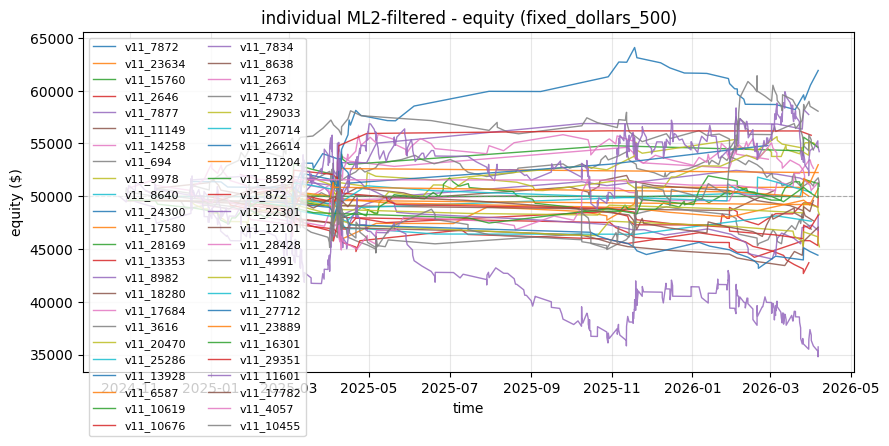

In [3]:
plot_ml2_indiv_equity(s4_pnl_by_combo, bars, 'fixed_dollars_500')

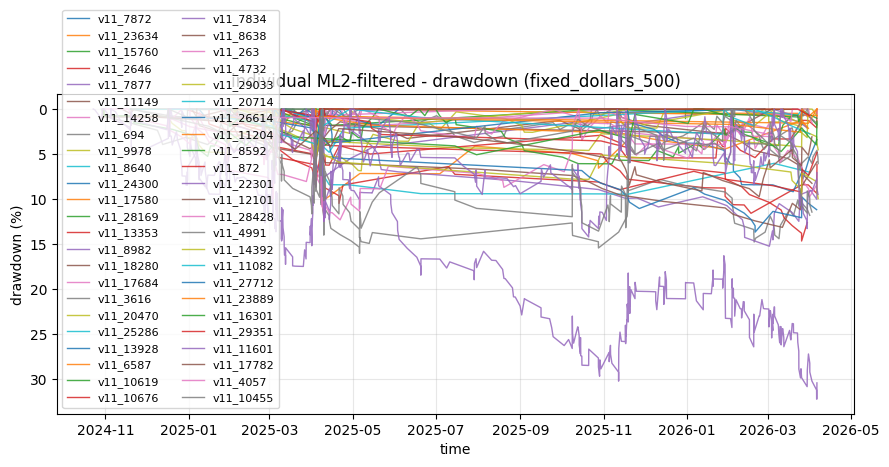

In [4]:
plot_ml2_indiv_dd(s4_pnl_by_combo, bars, 'fixed_dollars_500')